In [1]:
! pip install opencv-python numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

print("Libraries loaded")
print("OpenCV version:", cv2.__version__)

Libraries loaded
OpenCV version: 4.13.0


In [3]:
def debug_image(name, img):

    if img is None:
        print(f"{name} failed to load")
    else:
        print(f"{name} loaded")
        print("Shape:", img.shape)
        print("Type:", img.dtype)
        print()

In [4]:
def generate_stereo_images():

    height, width = 480, 640

    left_img = np.ones((height, width), dtype=np.uint8) * 150

    square = 40

    for i in range(0, height, square):
        for j in range(0, width, square):
            if (i//square + j//square) % 2 == 0:
                left_img[i:i+square, j:j+square] = 100

    cv2.circle(left_img,(150,150),60,255,-1)
    cv2.rectangle(left_img,(380,200),(520,320),220,-1)

    pts = np.array([[520,80],[620,80],[570,200]],np.int32)
    cv2.fillPoly(left_img,[pts],120)

    cv2.circle(left_img,(100,350),40,200,-1)

    right_img = np.ones((height,width),dtype=np.uint8)*150

    for i in range(0,height,square):
        for j in range(0,width,square):
            if (i//square + j//square)%2==0:
                right_img[i:i+square,j:j+square]=100

    cv2.circle(right_img,(130,150),60,255,-1)
    cv2.rectangle(right_img,(368,200),(508,320),220,-1)

    pts2 = np.array([[515,80],[615,80],[565,200]],np.int32)
    cv2.fillPoly(right_img,[pts2],120)

    cv2.circle(right_img,(82,350),40,200,-1)

    print("Synthetic stereo images generated")

    return left_img,right_img

In [5]:
use_synthetic = True

if use_synthetic:
    
    left_img, right_img = generate_stereo_images()

else:

    left_img = cv2.imread("left.png", cv2.IMREAD_GRAYSCALE)
    right_img = cv2.imread("right.png", cv2.IMREAD_GRAYSCALE)

debug_image("Left", left_img)
debug_image("Right", right_img)

Synthetic stereo images generated
Left loaded
Shape: (480, 640)
Type: uint8

Right loaded
Shape: (480, 640)
Type: uint8



In [6]:
if left_img.shape != right_img.shape:

    h = min(left_img.shape[0], right_img.shape[0])
    w = min(left_img.shape[1], right_img.shape[1])

    left_img = left_img[:h,:w]
    right_img = right_img[:h,:w]

    print("Images resized to same size:", left_img.shape)

In [7]:
left_img = cv2.equalizeHist(left_img)
right_img = cv2.equalizeHist(right_img)

left_img = cv2.GaussianBlur(left_img,(5,5),0)
right_img = cv2.GaussianBlur(right_img,(5,5),0)

left_img = cv2.equalizeHist(left_img)
right_img = cv2.equalizeHist(right_img)

print("Contrast enhanced")

Contrast enhanced


In [8]:
print("Computing disparity...")

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=128,
    blockSize=5,
    P1=8*3*5**2,
    P2=32*3*5**2
)

stereo = cv2.StereoBM_create(numDisparities=128, blockSize=15)

disparity = stereo.compute(left_img,right_img).astype(np.float32)/16

disp_norm = cv2.normalize(disparity,None,0,255,cv2.NORM_MINMAX)

disp_norm = disp_norm.astype(np.uint8)

disp_norm = cv2.medianBlur(disp_norm,5)

print("Disparity computed")
print("Disparity range:", np.min(disparity), np.max(disparity))

Computing disparity...
Disparity computed
Disparity range: -1.0 88.3125


In [9]:
baseline = 65.0
focal_length = 1000.0

disparity[disparity <= 0] = 0.1

depth = (baseline * focal_length) / disparity

print("Depth map calculated")

Depth map calculated


In [10]:
print("Applying filters")

depth_filtered = cv2.bilateralFilter(depth.astype(np.float32),9,75,75)

median = np.median(depth_filtered[depth_filtered>0])

depth_filtered[depth_filtered > median*3] = 0
depth_filtered[depth_filtered < median*0.1] = 0

print("Filtering complete")

Applying filters
Filtering complete


In [11]:
disp_norm = cv2.normalize(disparity,None,0,255,cv2.NORM_MINMAX)

depth_norm = cv2.normalize(depth_filtered,None,0,255,cv2.NORM_MINMAX)

depth_norm = depth_norm.astype(np.uint8)

depth_color = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)

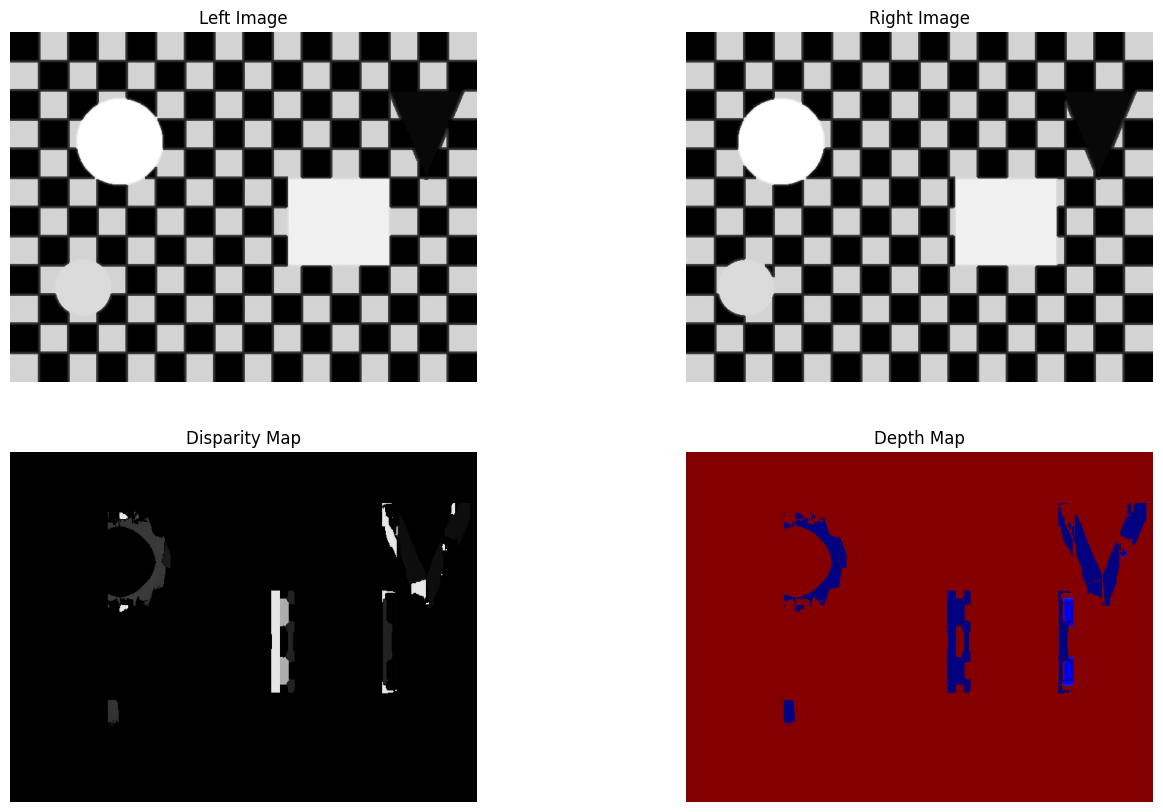

In [12]:
plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plt.imshow(left_img,cmap='gray')
plt.title("Left Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(right_img,cmap='gray')
plt.title("Right Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(disp_norm,cmap='gray')
plt.title("Disparity Map")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(depth_color,cv2.COLOR_BGR2RGB))
plt.title("Depth Map")
plt.axis("off")

plt.show()

In [13]:
valid_disp = disparity[disparity > 0]
valid_depth = depth_filtered[depth_filtered > 0]

print("\nDepth Statistics")

print("Min disparity:", np.min(valid_disp))
print("Max disparity:", np.max(valid_disp))
print("Mean disparity:", np.mean(valid_disp))

print()

print("Min depth:", np.min(valid_depth))
print("Max depth:", np.max(valid_depth))
print("Mean depth:", np.mean(valid_depth))
print("Median depth:", np.median(valid_depth))
print("Std depth:", np.std(valid_depth))


Depth Statistics
Min disparity: 0.1
Max disparity: 88.3125
Mean disparity: 1.4070736

Min depth: 64999.996
Max depth: 650000.1
Mean depth: 648289.2
Median depth: 649999.94
Std depth: 31313.877


In [14]:
cv2.imwrite("disparity_map.png", disp_norm)
cv2.imwrite("depth_map.png", depth_color)

print("Results saved")

Results saved
